# 01 · PyTorch training foundations

**Goal.** Build a working mental model of what happens in *one* PyTorch training
process — tensors, autograd, modules, optimizers, train/eval mode, data loading,
checkpoints, mixed precision, devices — by writing a training loop by hand. At the
end we run the repository's `Trainer`, which does exactly the same thing with
production concerns (determinism, checkpoint atomicity, DDP awareness) added.

Everything later in the platform (DDP in notebook 02, Ray Train in 04, tracking in
06) is built on this single-process loop, so it is worth being precise here.

| Section | Concept |
|---|---|
| 1 | Conceptual model of a training step |
| 2 | Tensors |
| 3 | Autograd (+ derivation checked numerically) |
| 4 | `nn.Module`, parameters, `state_dict` |
| 5 | Train vs eval mode (dropout) |
| 6 | Data, `Dataset`, `DataLoader`, batching |
| 7 | A manual training loop on the synthetic oracle |
| 8 | Checkpoint state |
| 9 | Mixed precision |
| 10 | GPU execution |
| 11 | The repository `Trainer` |
| 12–14 | Connection to the repo · failure modes · exercise |

## 1. Conceptual model

A training step is a pure function of *(parameters, optimizer state, batch, RNG state)*
that produces new parameters and optimizer state:

```text
             ┌────────────── RNG (shuffle order, dropout masks) ──────────────┐
             ▼                                                                ▼
Dataset ─► DataLoader ─► batch (x, y) ─► model.forward ─► ŷ ─► loss ℓ(ŷ, y)
                                          ▲    (builds autograd graph)       │
                                          │                                  ▼
                          params θ ◄── optimizer.step() ◄── θ.grad ◄── loss.backward()
                             ▲                 │
                             └── optimizer state (Adam moments m, v, step count)
```

Everything that must be saved to *resume* training exactly is on this picture:
θ, optimizer state, the epoch/step counter, RNG state and — easy to forget — the
data normalization statistics that define the input space of θ.

In [1]:
import os, sys, time, json, shutil, tempfile, warnings
from pathlib import Path

os.environ.setdefault("MLFLOW_DISABLE_AGENT_HINT", "1")
os.environ.setdefault("MERGE_LOG_LEVEL", "WARNING")   # keep structlog output out of the notebook
warnings.filterwarnings("ignore", category=UserWarning)

WORK = Path(tempfile.mkdtemp(prefix="nb01_"))       # every artifact of this notebook lives here
print("scratch dir:", WORK)

scratch dir: /var/folders/vx/0jy3t_qx56q4d0qpnmgs008r0000gn/T/nb01_26maxmpi


In [2]:
import numpy as np
import torch
from torch import nn

torch.manual_seed(0)
np.random.seed(0)
torch.set_num_threads(min(4, os.cpu_count() or 1))
print("torch", torch.__version__, "| cuda available:", torch.cuda.is_available(),
      "| mps available:", torch.backends.mps.is_available())

torch 2.14.0 | cuda available: False | mps available: True


## 2. Tensors

A tensor is an n-dimensional array with a **dtype**, a **shape**, a **device**, and
(optionally) a slot in the autograd graph. Operations broadcast like NumPy. The
things that bite in practice are dtype (float64 NumPy arrays become float64 tensors,
and models are float32) and device mismatch.

In [3]:
x_np = np.random.default_rng(0).normal(size=(4, 3))          # float64
x = torch.from_numpy(x_np)                                     # shares memory with x_np
print("from numpy :", x.dtype, tuple(x.shape), x.device)
x32 = x.float()                                                # copy -> float32 (model dtype)
w = torch.randn(3, 2)
b = torch.zeros(2)
out = x32 @ w + b                                              # (4,3)@(3,2) + (2,) broadcast
print("x32 @ w + b:", tuple(out.shape), out.dtype)
x_np[0, 0] = 100.0
print("shared memory -> x[0,0] =", float(x[0, 0]), "| x32 copy unchanged:", float(x32[0, 0]) != 100.0)
try:
    x @ w                                                      # float64 @ float32
except RuntimeError as e:
    print("dtype mismatch error:", str(e).splitlines()[0])

from numpy : torch.float64 (4, 3) cpu
x32 @ w + b: (4, 2) torch.float32
shared memory -> x[0,0] = 100.0 | x32 copy unchanged: True
dtype mismatch error: expected m1 and m2 to have the same dtype, but got: double != float


## 3. Autograd

Autograd records every operation on tensors with `requires_grad=True` into a DAG
during the forward pass, and `backward()` applies the chain rule in reverse
(reverse-mode AD: one backward pass gives the gradient w.r.t. *all* parameters at
roughly the cost of one forward pass).

**Derivation (linear model, MSE).** With $\hat y = Xw + b$ and
$L = \frac{1}{B}\sum_{i=1}^{B}(\hat y_i - y_i)^2$, let $r = Xw + b - y$. Then

$$
\frac{\partial L}{\partial w} = \frac{2}{B} X^\top r, \qquad
\frac{\partial L}{\partial b} = \frac{2}{B} \mathbf{1}^\top r .
$$

The $\frac{1}{B}$ matters: it is the reason the *mean* loss over a batch has a
gradient that does not grow with batch size — and, in notebook 02, the reason DDP
**averages** (rather than sums) gradients across workers.

In [4]:
B, d = 16, 5
X = torch.randn(B, d)
y = torch.randn(B)
w = torch.randn(d, requires_grad=True)
b = torch.zeros((), requires_grad=True)

loss = ((X @ w + b - y) ** 2).mean()
print("graph node of loss:", loss.grad_fn)
loss.backward()

r = (X @ w + b - y).detach()
grad_w_analytic = 2.0 / B * X.T @ r
grad_b_analytic = 2.0 / B * r.sum()
print("max |autograd - analytic| for w:", float((w.grad - grad_w_analytic).abs().max()))
print("max |autograd - analytic| for b:", float((b.grad - grad_b_analytic).abs()))

# gradients ACCUMULATE across backward() calls -> that is why loops call zero_grad()
((X @ w + b - y) ** 2).mean().backward()
print("after a 2nd backward, grad doubled:", torch.allclose(w.grad, 2 * grad_w_analytic))

graph node of loss: <MeanBackward0 object at 0x10f052350>
max |autograd - analytic| for w: 0.0
max |autograd - analytic| for b: 0.0
after a 2nd backward, grad doubled: True


## 4. `nn.Module`, parameters and `state_dict`

A module is a container of **parameters** (trainable tensors), **buffers** (state
that is saved but not trained, e.g. BatchNorm running statistics) and sub-modules.
`state_dict()` is the ordered name → tensor map of both — it is what a checkpoint
stores, and it is keyed by attribute *names*, so renaming an attribute breaks
loading old checkpoints.

In [5]:
class TinyMLP(nn.Module):
    def __init__(self, d_in: int, hidden: int = 64, p_drop: float = 0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, hidden), nn.GELU(), nn.Dropout(p_drop),
            nn.Linear(hidden, hidden), nn.GELU(), nn.Dropout(p_drop),
            nn.Linear(hidden, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x).squeeze(-1)          # (B,) like the repo's ResidualMLP

model = TinyMLP(d_in=32)
n_params = sum(p.numel() for p in model.parameters())
print(f"{n_params:,} parameters")
for k, v in model.state_dict().items():
    print(f"  {k:<14} {tuple(v.shape)}")

6,337 parameters
  net.0.weight   (64, 32)
  net.0.bias     (64,)
  net.3.weight   (64, 64)
  net.3.bias     (64,)
  net.6.weight   (1, 64)
  net.6.bias     (1,)


## 5. Train vs eval mode — dropout

`model.train()` / `model.eval()` flip a flag on every sub-module. Only layers whose
behaviour depends on it care: **Dropout** (random masks in train mode, identity in
eval) and **BatchNorm** (batch statistics vs running statistics).

Dropout with rate $p$ zeroes each activation with probability $p$ and scales the
survivors by $\frac{1}{1-p}$ so that $\mathbb{E}[\text{output}]$ equals the eval-mode
output. Forgetting `model.eval()` at inference time makes predictions *random*.
The repository deliberately exploits this for **MC dropout** uncertainty
(`merge_platform.models.uncertainty.mc_dropout_predict`): keep dropout on at
inference, predict $T$ times, use the spread as an epistemic-uncertainty estimate.

Note: `torch.no_grad()` is a *different* switch — it stops graph recording (memory,
speed) but does **not** turn dropout off.

In [6]:
xq = torch.randn(3, 32)
model.train()
with torch.no_grad():
    a, b_ = model(xq), model(xq)
print("train mode, two passes identical?", torch.equal(a, b_), "| a =", a.numpy().round(3))
model.eval()
with torch.no_grad():
    a, b_ = model(xq), model(xq)
print("eval  mode, two passes identical?", torch.equal(a, b_), "| a =", a.numpy().round(3))

# MC dropout: T stochastic passes in train mode -> mean and spread
model.train()
with torch.no_grad():
    samples = torch.stack([model(xq) for _ in range(50)])
print("MC dropout mean:", samples.mean(0).numpy().round(3), " std:", samples.std(0).numpy().round(3))

train mode, two passes identical? False | a = [ 0.074  0.039 -0.013]
eval  mode, two passes identical? True | a = [0.097 0.049 0.032]
MC dropout mean: [0.091 0.049 0.04 ]  std: [0.034 0.026 0.036]


## 6. Data, `Dataset`, `DataLoader` and batching

We use the platform's synthetic "expensive experiment": a hidden nonlinear oracle
$y = f(x) + \varepsilon(x)$ with heteroscedastic noise over 32 features
(`merge_platform.data.synthetic_oracle.SyntheticOracle`). `PlatformConfig.for_tests`
gives a tiny configuration (2 000-candidate pool, 300 initial observations).

A `Dataset` answers `len()` and `__getitem__(i)`; a `DataLoader` turns it into an
iterator of **batches** using a **sampler** (the order of indices) and a
**collate** function (stacking samples). With $n$ rows and batch size $B$ an epoch has
$\lceil n/B \rceil$ steps (or $\lfloor n/B \rfloor$ with `drop_last=True`).

In [7]:
from merge_platform.config import PlatformConfig
from merge_platform.data import (
    generate_candidate_pool, initial_observations, make_oracle, records_to_frame, train_val_split,
)

cfg = PlatformConfig.for_tests(WORK)            # all paths/URIs point into WORK
pool = generate_candidate_pool(cfg)
oracle = make_oracle(cfg)
records = initial_observations(pool, oracle, n=cfg.data.initial_observations, seed=cfg.seed)
frame = records_to_frame(records)
train_frame, val_frame = train_val_split(frame, cfg.training.val_fraction, cfg.seed)
fcols = [c for c in frame.columns if c.startswith("f") and c[1:].isdigit()]
print("pool:", pool.shape, "| observations:", frame.shape, "| train/val:", len(train_frame), len(val_frame))
frame[["experiment_id", "round_id", "f00", "f01", "response", "measurement_std", "status"]].head(3)

pool: (2000, 34) | observations: (300, 39) | train/val: 228 72


,experiment_id,round_id,f00,f01,response,measurement_std,status
0,cand_000001,0,1.296421,-1.097775,3.898670,0.239895,measured
1,cand_000009,0,-0.372705,-1.315264,1.022964,0.182074,measured
2,cand_000012,0,0.457139,1.953699,-0.033802,0.105548,measured


In [8]:
from torch.utils.data import DataLoader, TensorDataset

# standardize with TRAINING statistics only (validation must not leak into them)
Xtr = train_frame[fcols].to_numpy(np.float32); ytr = train_frame["response"].to_numpy(np.float32)
Xva = val_frame[fcols].to_numpy(np.float32);   yva = val_frame["response"].to_numpy(np.float32)
x_mu, x_sd = Xtr.mean(0), Xtr.std(0) + 1e-8
y_mu, y_sd = ytr.mean(), ytr.std() + 1e-8
norm = lambda X_, y_: (torch.from_numpy((X_ - x_mu) / x_sd), torch.from_numpy((y_ - y_mu) / y_sd))
train_ds = TensorDataset(*norm(Xtr, ytr))
val_ds = TensorDataset(*norm(Xva, yva))

g = torch.Generator().manual_seed(0)            # explicit generator -> reproducible shuffle order
loader = DataLoader(train_ds, batch_size=64, shuffle=True, generator=g, drop_last=False)
xb, yb = next(iter(loader))
print("batch shapes:", tuple(xb.shape), tuple(yb.shape), "| steps/epoch:", len(loader),
      "= ceil(", len(train_ds), "/ 64 )")
print("last batch size:", [len(b[1]) for b in loader][-1])

batch shapes: (64, 32) (64,) | steps/epoch: 4 = ceil( 228 / 64 )
last batch size: 36


## 7. A manual training loop

The five lines at the core of every PyTorch loop:

```python
optimizer.zero_grad(set_to_none=True)   # 1. clear accumulated grads
pred = model(xb)                        # 2. forward (records graph)
loss = loss_fn(pred, yb)                # 3. scalar loss
loss.backward()                         # 4. reverse-mode AD -> p.grad
optimizer.step()                        # 5. update params (+ optimizer state)
```

AdamW keeps two moment estimates per parameter ($m_t$, $v_t$) and applies
$\theta \leftarrow \theta - \eta\,\big(\hat m_t / (\sqrt{\hat v_t} + \epsilon) + \lambda\theta\big)$ —
so its state is 2× the model size, and it must be checkpointed for exact resumption.

In [9]:
def evaluate(model: nn.Module, ds: TensorDataset) -> float:
    model.eval()                                  # dropout off
    with torch.no_grad():                         # no graph
        X_, y_ = ds.tensors
        return float(torch.sqrt(((model(X_) - y_) ** 2).mean()))

torch.manual_seed(0)
model = TinyMLP(d_in=32)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-4)
loss_fn = nn.MSELoss()
history = []
t0 = time.perf_counter()
for epoch in range(1, 41):
    model.train()
    running, n = 0.0, 0
    for xb, yb in loader:
        optimizer.zero_grad(set_to_none=True)
        loss = loss_fn(model(xb), yb)
        loss.backward()
        optimizer.step()
        running += loss.item() * len(yb); n += len(yb)
    history.append({"epoch": epoch, "train_mse": running / n, "val_rmse": evaluate(model, val_ds)})
print(f"{len(history)} epochs in {time.perf_counter() - t0:.1f}s")
for h in history[::10] + [history[-1]]:
    print(f"epoch {h['epoch']:>2}  train_mse={h['train_mse']:.3f}  val_rmse(std units)={h['val_rmse']:.3f}")

40 epochs in 0.1s
epoch  1  train_mse=0.943  val_rmse(std units)=0.927
epoch 11  train_mse=0.077  val_rmse(std units)=0.415
epoch 21  train_mse=0.050  val_rmse(std units)=0.394
epoch 31  train_mse=0.029  val_rmse(std units)=0.396
epoch 40  train_mse=0.024  val_rmse(std units)=0.403


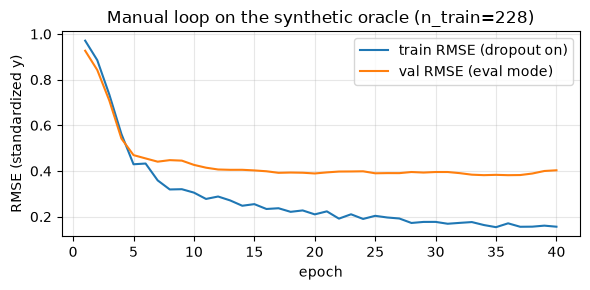

In [10]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
%matplotlib inline

ep = [h["epoch"] for h in history]
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(ep, [h["train_mse"] ** 0.5 for h in history], label="train RMSE (dropout on)")
ax.plot(ep, [h["val_rmse"] for h in history], label="val RMSE (eval mode)")
ax.set_xlabel("epoch"); ax.set_ylabel("RMSE (standardized y)"); ax.legend(); ax.grid(alpha=.3)
ax.set_title("Manual loop on the synthetic oracle (n_train=%d)" % len(train_ds))
plt.tight_layout(); plt.show()

With only ~230 training rows the model starts to overfit — the validation curve
flattens while training loss keeps falling. That is the "sparse, expensive data"
regime the platform is designed for (and why notebook 09 acquires data actively).

## 8. Checkpoint state

To **resume** (not just to *serve*) we need more than weights. Compare what the
optimizer holds:

In [11]:
opt_state = optimizer.state_dict()
first = opt_state["state"][0]
print("optimizer.state_dict() keys:", list(opt_state))
print("per-param state keys      :", list(first), "| step =", float(first["step"]))
print("param_groups[0]           :", {k: v for k, v in opt_state["param_groups"][0].items() if k != "params"})

ckpt = {
    "model_state": model.state_dict(),
    "optimizer_state": optimizer.state_dict(),
    "epoch": len(history),
    "normalizer": {"x_mu": x_mu.tolist(), "x_sd": x_sd.tolist(), "y_mu": float(y_mu), "y_sd": float(y_sd)},
    "rng_state": {"torch": torch.get_rng_state(), "loader": g.get_state()},
}
path = WORK / "manual_ckpt.pt"
torch.save(ckpt, path)
print(f"checkpoint: {path.name}  {path.stat().st_size/1e3:.0f} kB")

# restore into a fresh model and check predictions are bit-identical
restored = TinyMLP(d_in=32)
restored.load_state_dict(torch.load(path, weights_only=True)["model_state"])
model.eval(); restored.eval()
with torch.no_grad():
    same = torch.equal(model(val_ds.tensors[0]), restored(val_ds.tensors[0]))
print("restored model predictions identical:", same)

optimizer.state_dict() keys: ['state', 'param_groups']
per-param state keys      : ['step', 'exp_avg', 'exp_avg_sq'] | step = 160.0
param_groups[0]           : {'lr': 0.003, 'betas': (0.9, 0.999), 'eps': 1e-08, 'weight_decay': 0.0001, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True}
checkpoint: manual_ckpt.pt  95 kB
restored model predictions identical: True


`weights_only=True` restricts `torch.load` to tensors and plain containers — it
refuses to unpickle arbitrary objects, which is both a security property and a
forcing function for a clean checkpoint schema (the repo's
`training.config.get_rng_state` converts RNG states into tensors/lists for this reason).

## 9. Mixed precision

`torch.autocast` runs selected ops (matmuls, convolutions) in a lower-precision dtype
while keeping numerically sensitive ops (reductions, losses) in float32. Parameters
stay float32 ("master weights"). On CPU the supported low-precision dtype is
**bfloat16** (8 exponent bits like float32, so no overflow issue, but only 8 bits of
mantissa → ~3 significant digits). On CUDA with **float16** (5 exponent bits) small
gradients underflow, so you also need `torch.amp.GradScaler` to scale the loss.

In [12]:
xb, yb = next(iter(loader))
model.train()
with torch.autocast(device_type="cpu", dtype=torch.bfloat16):
    h = model.net[0](xb)                 # Linear -> runs in bf16 under autocast
    pred = model(xb)
    loss = loss_fn(pred.float(), yb)
print("activation dtype under autocast:", h.dtype, "| loss dtype:", loss.dtype,
      "| parameter dtype:", next(model.parameters()).dtype)
loss.backward()                          # grads land on the fp32 params
print("grad dtype:", next(model.parameters()).grad.dtype)

model.eval()
with torch.no_grad():
    p32 = model(val_ds.tensors[0])
    with torch.autocast(device_type="cpu", dtype=torch.bfloat16):
        p16 = model(val_ds.tensors[0]).float()
print(f"max |fp32 - bf16| prediction difference: {float((p32 - p16).abs().max()):.4f} (std units)")
print("bf16 machine epsilon:", torch.finfo(torch.bfloat16).eps, "| fp32:", torch.finfo(torch.float32).eps)

activation dtype under autocast: torch.bfloat16 | loss dtype: torch.float32 | parameter dtype: torch.float32
grad dtype: torch.float32
max |fp32 - bf16| prediction difference: 0.0054 (std units)
bf16 machine epsilon: 0.0078125 | fp32: 1.1920928955078125e-07


For a few-thousand-parameter MLP mixed precision buys nothing (it is latency-bound, not
FLOP-bound); it matters for large models on GPUs with tensor cores. It is also a
**reproducibility** lever: bf16 predictions differ from fp32 ones at the 1e-3–1e-2 level,
so the precision mode belongs in the run metadata.

## 10. GPU execution

Moving to a GPU is `model.to(device)` + moving every batch. CUDA kernels are launched
**asynchronously** — the Python call returns before the GPU finishes, so wall-clock
timings need `torch.cuda.synchronize()`. The repo resolves the device in
`merge_platform.training.config.resolve_device`: `auto` → `cuda:<local_rank>` if CUDA
exists, else CPU. Apple **MPS** is never chosen automatically (not bit-reproducible,
not supported by DDP).

In [13]:
from merge_platform.training.config import resolve_device

device = resolve_device(cfg.with_overrides(**{"training.device": "auto"}))
print("resolve_device(auto) ->", device)
if device.type == "cuda":
    m = TinyMLP(32).to(device)
    xg = val_ds.tensors[0].to(device)
    torch.cuda.synchronize(); t0 = time.perf_counter()
    for _ in range(100):
        m(xg)
    torch.cuda.synchronize()
    print(f"100 forward passes on {torch.cuda.get_device_name(device)}: {time.perf_counter()-t0:.3f}s")
else:
    print("No CUDA device here - the same code runs on CPU; on a GPU host this cell times CUDA kernels.")

resolve_device(auto) -> cpu
No CUDA device here - the same code runs on CPU; on a GPU host this cell times CUDA kernels.


## 11. The repository `Trainer` does the same thing

`merge_platform.training.trainer.Trainer` wraps the loop above and adds:

* `setup()` — `seed_everything`, `configure_determinism` (deterministic kernels),
  fits a `Normalizer` on the training split only, builds `ResidualMLP` via
  `models.mlp.build_model`, creates AdamW;
* `_train_loader()` — a seeded `RandomSampler` re-seeded per epoch (or a
  `DistributedSampler` under DDP, notebook 02);
* `_train_epoch()` / `validate()` — the loop, with metrics as sufficient statistics
  so they can be all-reduced across ranks;
* `save_checkpoint()` — atomic `epoch_XXXX/model.pt` + `latest` pointer via
  `training.checkpointing.save_checkpoint`;
* `train(..., resume_from=..., fail_at_epoch=...)` — resumption and failure injection.

In [14]:
from merge_platform.data import ArrayDataset
from merge_platform.training import Trainer, load_checkpoint, predict_array
from merge_platform.inference import Predictor

tcfg = cfg.with_overrides(**{"training.epochs": 10})
trainer = Trainer(tcfg)
result = trainer.train(
    ArrayDataset.from_frame(train_frame, dataset_hash="nb01-demo"),
    ArrayDataset.from_frame(val_frame, dataset_hash="nb01-demo"),
    checkpoint_dir=WORK / "trainer_ckpt",
)
print(f"epochs={result.epochs_completed}  device={result.device}  params={result.n_parameters:,}  "
      f"duration={result.duration_s:.1f}s")
print("final metrics:", {k: round(v, 4) for k, v in result.metrics.items()})
print("checkpoint dir:", sorted(p.name for p in (WORK / "trainer_ckpt").iterdir()))

epochs=10  device=cpu  params=3,393  duration=0.1s
final metrics: {'train_loss': 0.0698, 'val_loss': 0.1824, 'val_rmse': 0.4271, 'val_mae': 0.3099, 'val_r2': 0.8099, 'val_rmse_raw': 0.853, 'n_val': 72.0}
checkpoint dir: ['epoch_0001', 'epoch_0002', 'epoch_0003', 'epoch_0004', 'epoch_0005', 'epoch_0006', 'epoch_0007', 'epoch_0008', 'epoch_0009', 'epoch_0010', 'latest']


In [15]:
payload = load_checkpoint(result.checkpoint_path)
print("checkpoint payload keys:", sorted(payload))
print("model_spec:", payload["model_spec"])
print("normalizer keys:", sorted(payload["normalizer"]))
print("rng_state keys:", sorted(payload["rng_state"]))

# Serving path: Predictor.from_checkpoint rebuilds the model from `model_spec`
predictor = Predictor.from_checkpoint(result.checkpoint_path)
Xv = val_frame[fcols].to_numpy()
p_trainer = predict_array(trainer, Xv)
p_serving = predictor.predict(val_frame)
print("Trainer vs Predictor predictions (raw units) max diff:", float(np.abs(p_trainer - p_serving).max()))
mu, sd = predictor.predict_with_uncertainty(val_frame.head(5), n_samples=20)
print("MC-dropout mean:", mu.round(2), "\nMC-dropout std :", sd.round(2))

checkpoint payload keys: ['config', 'dataset_hash', 'epoch', 'format_version', 'history', 'metrics', 'model_spec', 'model_state', 'normalizer', 'optimizer_state', 'rng_state', 'rng_states', 'seed', 'world_size']
model_spec: {'class': 'ResidualMLP', 'kwargs': {'in_dim': 32, 'hidden_dims': [32, 32], 'dropout': 0.1, 'predict_variance': False}}
normalizer keys: ['x_mean', 'x_std', 'y_mean', 'y_std']
rng_state keys: ['numpy', 'python', 'torch']
Trainer vs Predictor predictions (raw units) max diff: 0.0
MC-dropout mean: [1.39 0.68 2.3  1.9  1.29] 
MC-dropout std : [0.2  0.28 0.24 0.16 0.28]


## 12. Connection to this repository

| Concept in this notebook | Repository implementation |
|---|---|
| model with dropout, `(B,)` output | `src/merge_platform/models/mlp.py` — `ResidualMLP`, `build_model`, `model_from_spec` |
| MC dropout | `src/merge_platform/models/uncertainty.py` — `mc_dropout_predict` |
| normalization fitted on train only | `src/merge_platform/data/normalization.py` — `Normalizer.fit` |
| `Dataset` | `src/merge_platform/data/datasets.py` — `ArrayDataset`, `train_val_split` |
| seeding / determinism / device | `src/merge_platform/training/config.py` — `seed_everything`, `configure_determinism`, `resolve_device`, `get_rng_state` |
| training loop | `src/merge_platform/training/trainer.py` — `Trainer._train_epoch`, `Trainer.validate`, `Trainer.train` |
| checkpoint format | `src/merge_platform/training/checkpointing.py` — `save_checkpoint` (atomic), `load_checkpoint(weights_only=True)`, `checkpoint_hash` |
| inference | `src/merge_platform/inference/predictor.py` — `Predictor.from_checkpoint`, `predict_with_uncertainty` |
| config | `src/merge_platform/config.py` — `PlatformConfig`, `configs/local.yaml` |

## 13. Failure modes

* **Forgetting `zero_grad()`** — gradients accumulate across steps (shown in §3); training silently diverges.
* **Forgetting `model.eval()`** — dropout stays on, predictions are random (§5); BatchNorm uses batch stats.
* **Normalizing with validation/test statistics** — leakage; optimistic metrics. The repo fits `Normalizer` on the training split only and stores it *in the checkpoint*.
* **Checkpointing weights only** — resuming resets Adam moments and the step count; the resumed run is not the same run.
* **dtype/device mismatches** — float64 NumPy input into a float32 model; a CPU tensor into a CUDA model.
* **Timing async CUDA without `synchronize()`** — measures kernel *launch*, not execution.
* **fp16 without `GradScaler`** — gradients underflow to zero; loss plateaus for no visible reason.
* **`torch.load` on untrusted files without `weights_only=True`** — arbitrary code execution via pickle.
* **Non-seeded shuffling / dataloader workers** — each run sees a different data order; results cannot be reproduced (notebook 06).

## 14. Exercise

1. Change the manual loop to use `nn.GaussianNLLLoss` with a second output head that
   predicts log-variance; compare with the repo's option `training.loss: gaussian_nll`
   (`models/losses.py::gaussian_nll_loss`, `ResidualMLP(predict_variance=True)`).
2. Save a checkpoint after epoch 20 of the manual loop, restart from it (restoring
   model, optimizer **and** the loader generator state) and verify that epochs 21–40
   reproduce the uninterrupted run bit-for-bit. Then drop the optimizer state and
   measure how far the resumed run diverges.
3. Train with `torch.autocast(device_type="cpu", dtype=torch.bfloat16)` around the
   forward pass; compare final validation RMSE and wall time with fp32.

In [16]:
shutil.rmtree(WORK, ignore_errors=True)
print("cleaned up", WORK)

cleaned up /var/folders/vx/0jy3t_qx56q4d0qpnmgs008r0000gn/T/nb01_26maxmpi
